## 1. Histogram of Number of arrivals for an M/M/1 queueing Model

This code:  
- Generates two independent Poisson processes  $ X_1 \sim \text{Poisson}(\lambda_1 T) $ and $X_2 \sim \text{Poisson}(\lambda_2 T)$.  
- Shows that their sum $X_1 + X_2$ follows a Poisson distribution with mean $(\lambda_1 + \lambda_2)T$.  

## Questions

1. How does the code ensure that arrivals and departures are correctly interleaved in time, given that arrivals are generated first but departures depend on both the arrival instant and the previous queue state?

2. Why does the departure time depend on `max(departure_times[-1], current_time)` rather than simply `current_time + service_time`, and how does this reflect the FIFO property of the M/M/1 queue?

3. In what way does the combination of `num_in_system` and the cleanup loop (`while departure_times and departure_times[0] <= current_time`) guarantee an accurate count of packets in the system?

4. What role does the condition `if current_time < simulation_time:` play in ensuring that the simulation produces valid statistics? What could go wrong if this check were omitted?

5. At the end of the simulation, how do the three outputs — `arrival_times`, `departure_times`, and `num_in_system` — together provide a full picture of the queue’s performance?
  
6. How does the empirical distribution of the number of arrivals (from the simulation) compare with the theoretical Poisson distribution with mean `λT`?  
7. In what ways can we verify, using the simulation results, that the M/M/1 queue follows the theoretical properties (e.g., interarrival times are exponential, queue length distribution matches the steady-state formula, or utilization approaches `λ/μ`)?  

8. Why might there be discrepancies between the theoretical distribution and the simulation histogram, and how do factors like finite simulation time or random variability influence this match?
      



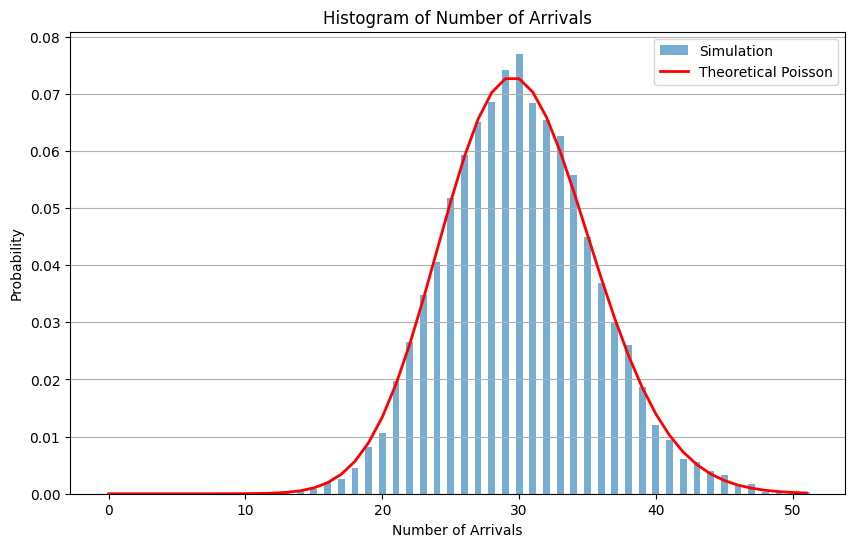

Simulated mean total arrivals: 30.0642
Theoretical mean total arrivals (Poisson): 30.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
# Parameters for the QUEUES
arrival_rate1 = 0.1  # arrival rate for the first queue (arrivals per unit time)
service_rate1 = 0.5 # service rate for the first queue (services per unit time)
arrival_rate2 = 0.2 # arrival rate for the second queue (arrivals per unit time)
service_rate2 = 0.6  # service rate for the second queue (services per unit time)
simulation_time = 100 # total simulation time
num_simulations = 10000  # number of simulations to run

# Function to simulate the behavior of a queue
def simulate_mm1_queue(arrival_rate, service_rate, simulation_time):
    current_time = 0
    num_arrivals = 0
    num_in_system = 0
    arrival_times = []
    departure_times = []

    while current_time < simulation_time:
        interarrival_time = np.random.exponential(1 / arrival_rate)
        service_time = np.random.exponential(1 / service_rate)
        current_time += interarrival_time

        if current_time < simulation_time:
            arrival_times.append(current_time)
            num_arrivals += 1

            if num_in_system == 0:
                departure_time = current_time + service_time
            else:
                departure_time = max(departure_times[-1], current_time) + service_time

            departure_times.append(departure_time)
            num_in_system += 1

            while departure_times and departure_times[0] <= current_time:
                departure_times.pop(0)
                num_in_system -= 1

    return arrival_times, departure_times, num_in_system

# List to store the total number of arrivals for each simulation
Num_arrivals = []

for _ in range(num_simulations):
    arrival_times_1, departure_times_1, _ = simulate_mm1_queue(arrival_rate1, service_rate1, simulation_time)
    arrival_times_2, departure_times_2, _ = simulate_mm1_queue(arrival_rate2, service_rate2, simulation_time)
    Num_arrivals.append(len(arrival_times_1) + len(arrival_times_2))
    
# Plot histogram of arrivals
plt.figure(figsize=(10, 6))
freq, bins, _ = plt.hist(Num_arrivals, bins=range(int(max(Num_arrivals)) + 2), 
                         density=True, align='left', rwidth=0.5, alpha=0.6, label="Simulation")

# Overlay theoretical Poisson distribution for total arrivals
lambda_total =   (arrival_rate1+arrival_rate2)* simulation_time                                #----> Enter Theretical mean
k_vals_ar = np.arange(0, max(Num_arrivals) + 1)
poisson_probs_arrivals = (np.exp(-lambda_total) * (lambda_total ** k_vals_ar)) / np.array([math.factorial(k) for k in k_vals_ar])
plt.plot(k_vals_ar, poisson_probs_arrivals, 'r-', linewidth=2, label="Theoretical Poisson")
plt.title('Histogram of Number of Arrivals')
plt.xlabel('Number of Arrivals')
plt.ylabel('Probability')
plt.legend()
plt.grid(axis='y')
plt.show()


simulated_mean = float(np.mean(Num_arrivals))
print(f"Simulated mean total arrivals: {simulated_mean:.4f}")

lambda_total = (arrival_rate1 + arrival_rate2) * simulation_time
print(f"Theoretical mean total arrivals (Poisson): {lambda_total:.4f}")


###  2. Steady  state probability versus Empirical distribution

1. **Empirical distribution**

   * We count how often each state (number in buffer/system) occurred in the simulation.
   * This gives us the *simulated steady-state distribution*.

2. **Theoretical distribution**

   * For an M/M/1 queue, the steady-state probability is:

     $$
     P(N=n) = (1 - \rho)\,\rho^n, \quad n \geq 0
     $$
   * Here, $\rho = \frac{\lambda}{\mu}$ is the utilization.

3. **Task**: Compare the **bars (simulation)** with the **red curve (theory)**.

   * Do they line up closely?
   * Any deviations are due to finite simulation length.

### Explain this

```python
for _ in range(num_simulations):
    arrival_times, _, num_in_system = simulate_mm1_queue(arrival_rate, service_rate, simulation_time)
    all_states.append(num_in_system)                # final number in system
    num_arrivals_in_interval.append(len(arrival_times))  # number of arrivals in [0, T]


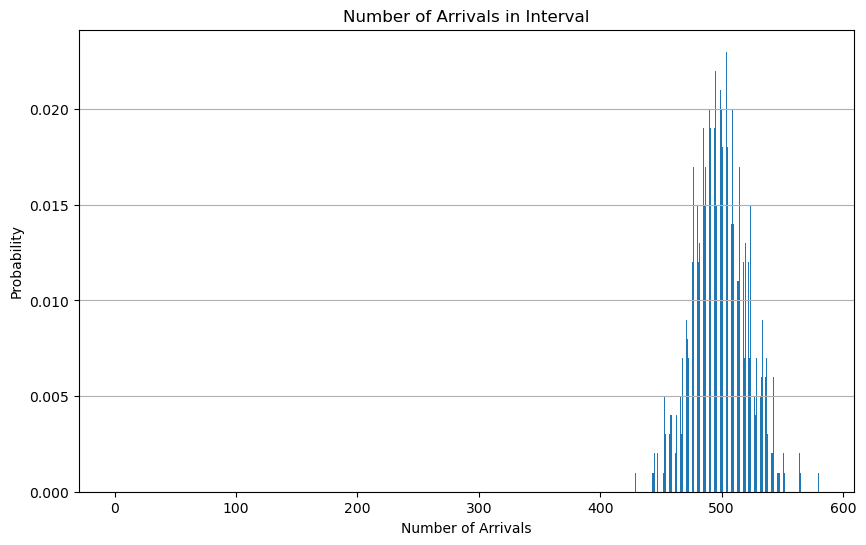

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
arrival_rate = 5  # arrivals per unit time (λ)
service_rate = 8  # services per unit time (μ)
rho = arrival_rate / service_rate
simulation_time = 100  # run long enough to reach steady state
num_simulations = 1000 # how many state samples we take

# Function to simulate the behavior of a queue
def simulate_mm1_queue(arrival_rate, service_rate, simulation_time):
    current_time = 0
    num_arrivals = 0
    num_in_system = 0
    arrival_times = []
    departure_times = []

    while current_time < simulation_time:
        interarrival_time = np.random.exponential(1 / arrival_rate)
        service_time = np.random.exponential(1 / service_rate)
        current_time += interarrival_time

        if current_time < simulation_time:
            arrival_times.append(current_time)
            num_arrivals += 1

            if num_in_system == 0:
                departure_time = current_time + service_time
            else:
                departure_time = max(departure_times[-1], current_time) + service_time

            departure_times.append(departure_time)
            num_in_system += 1

            while departure_times and departure_times[0] <= current_time:
                departure_times.pop(0)
                num_in_system -= 1

    return arrival_times, departure_times, num_in_system

# Run simulation and collect states
all_states = []
num_arrivals_in_interval = []
for _ in range(num_simulations):
    arrival_times, _, num_in_system = simulate_mm1_queue(arrival_rate, service_rate, simulation_time)
    all_states.append(num_in_system)                # final number in system
    num_arrivals_in_interval.append(len(arrival_times))  # number of arrivals in [0, T]


# Plot histogram of number of arrivals in the interval
plt.figure(figsize=(10, 6))
plt.hist(num_arrivals_in_interval, bins=range(max(num_arrivals_in_interval) + 2), density=True, align='left', rwidth=0.5)
plt.title('Number of Arrivals in Interval')
plt.xlabel('Number of Arrivals')
plt.ylabel('Probability')
plt.grid(axis='y')
plt.show()



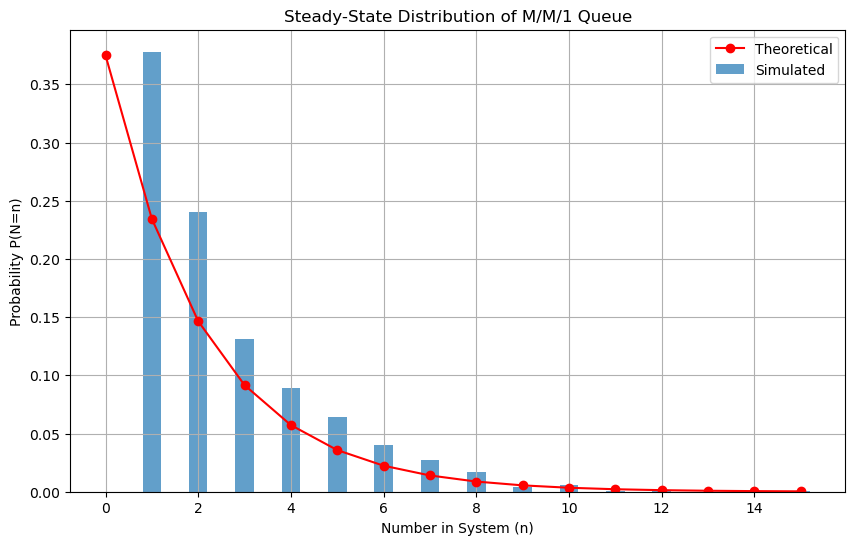

In [4]:
# Empirical distribution

unique, counts = np.unique(all_states, return_counts=True)
empirical_probs = counts / counts.sum()
rho =  arrival_rate/service_rate
# Theoretical distribution
n_vals = np.arange(0, max(unique)+1)
theoretical_probs = (1-rho) * rho**n_vals

# Plot comparison
plt.figure(figsize=(10,6))
plt.bar(unique, empirical_probs, width=0.4, label='Simulated', alpha=0.7)
plt.plot(n_vals, theoretical_probs, 'ro-', label='Theoretical')
plt.title('Steady-State Distribution of M/M/1 Queue')
plt.xlabel('Number in System (n)')
plt.ylabel('Probability P(N=n)')
plt.legend()
plt.grid(True)
plt.show()


##  3. Probability of transition from state  𝑛   to  𝑛+1   is  $\lambda/\lambda+ \mu$
Derive this and get the closed form expression to compare.
 

In [ ]:
# --- Probability of state increment n -> n+1 ---
import numpy as np
def estimate_increment_probability(arrival_rate, service_rate, trials=1000000):
    """
    Estimates P(X_arrival < X_departure) for n>=1 by Monte Carlo.
    (Independent exponentials with rates λ and μ.)
    """
    if arrival_rate <= 0 or service_rate <= 0:
        raise ValueError("Rates must be positive.")
    # Draw many inter-arrival and service times and see which is smaller
    a = np.random.exponential(1/arrival_rate, size=trials)
    s = np.random.exponential(1/service_rate, size=trials)
    return float(np.mean(a < s))

# --- Fill your rates here (same as the ones used above) ---
arrival_rate1 = 0.1
service_rate1 = 0.6
arrival_rate2 = 0.1
service_rate2 = 0.6

# Theoretical probabilities for n>=1
p_inc1_theory = arrival_rate1 / (arrival_rate1 + service_rate1)
p_inc2_theory = arrival_rate2 / (arrival_rate2 + service_rate2)

# Monte Carlo estimates (optional)
p_inc1_sim = estimate_increment_probability(arrival_rate1, service_rate1)
p_inc2_sim = estimate_increment_probability(arrival_rate2, service_rate2)

print(f"Queue 1: P(n→n+1 | n≥1) theory = {p_inc1_theory:.4f},  simulation = {p_inc1_sim:.4f}")
print(f"Queue 2: P(n→n+1 | n≥1) theory = {p_inc2_theory:.4f},  simulation = {p_inc2_sim:.4f}")
print("For n = 0, P(0→1) = 1.0000 (no departure possible).")


## Demonstration of PASTA Property for M/M/1 queue
In a system that satisfies the PASTA property, the probability distribution of the number of arrivals within a given time interval is the same as the steady-state probability distribution of the number of arrivals at any time within that interval.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
arrival_rate = 5  # arrivals per unit time (λ)
service_rate = 8  # services per unit time (μ)
rho = arrival_rate / service_rate
simulation_time = 100  # run long enough to reach steady state
num_simulations = 1000 # how many state samples we take

def simulate_mm1_queue(arrival_rate, service_rate, simulation_time):
    current_time = 0
    num_in_system = 0
    events = []  # system size samples
    arrival_times = []   # record arrivals
    # Initialize first arrival
    next_arrival = np.random.exponential(1/arrival_rate)
    next_departure = np.inf

    while current_time < simulation_time:
        if next_arrival < next_departure:
            # Arrival
            current_time = next_arrival
            arrival_times.append(current_time)
            num_in_system += 1
            next_arrival = current_time + np.random.exponential(1/arrival_rate)
            if num_in_system == 1:  # server idle → schedule departure
                next_departure = current_time + np.random.exponential(1/service_rate)
        else:
            # Departure
            current_time = next_departure
            num_in_system -= 1
            if num_in_system > 0:
                next_departure = current_time + np.random.exponential(1/service_rate)
            else:
                next_departure = np.inf

        events.append(num_in_system)

    return arrival_times, events

# Run simulation and collect states
all_states = []
num_arrivals_in_interval = []
for _ in range(num_simulations):
    arrival_times, states = simulate_mm1_queue(arrival_rate, service_rate, simulation_time)
    all_states.append(states[-1])  # sample last state as "steady state"
    num_arrivals_in_interval.append(len(arrival_times))


# Plot histogram of number of arrivals in the interval
plt.figure(figsize=(10, 6))
plt.hist(num_arrivals_in_interval, bins=range(max(num_arrivals_in_interval) + 2), density=True, align='left', rwidth=0.5)
plt.title('Number of Arrivals in Interval')
plt.xlabel('Number of Arrivals')
plt.ylabel('Probability')
plt.grid(axis='y')
plt.show()



In [ ]:
# Empirical distribution
unique, counts = np.unique(all_states, return_counts=True)
empirical_probs = counts / counts.sum()

# Theoretical distribution
n_vals = np.arange(0, max(unique)+1)
theoretical_probs = (1-rho) * rho**n_vals

# Plot comparison
plt.figure(figsize=(10,6))
plt.bar(unique, empirical_probs, width=0.4, label='Simulated', alpha=0.7)
plt.plot(n_vals, theoretical_probs, 'ro-', label='Theoretical')
plt.title('Steady-State Distribution of M/M/1 Queue')
plt.xlabel('Number in System (n)')
plt.ylabel('Probability P(N=n)')
plt.legend()
plt.grid(True)
plt.show()
